In [2]:
# Data that exhibits non-linear patterns might be better forecasted using more sophisticated models
# such as neural networks or machine learning algorithms.
# Long Short-Term Memory (LSTM) model is used to predict stock closing prices.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from math import sqrt

from openbb import obb
obb.user.preferences.output_type = "dataframe"

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [7]:
# Set parameters for data retrieval
num_years = 10
start_date = dt.datetime.now() - dt.timedelta(days=num_years * 365.25)
end_date = dt.datetime.now()

start_date = start_date.strftime('%Y-%m-%d')
end_date = end_date.strftime('%Y-%m-%d')

In [10]:
tickers = "^GSPC"
symbols = tickers

In [11]:
data = obb.equity.price.historical(
    symbols,
    start_date=start_date,
    end_date=end_date,
    provider="yfinance"
)

In [12]:
print(data.head())

               open     high      low  ...      volume  dividends  stock_splits
date                                   ...                                     
2014-03-17  1842.81  1862.30  1842.81  ...  2860490000        0.0           0.0
2014-03-18  1858.92  1873.76  1858.92  ...  2930190000        0.0           0.0
2014-03-19  1872.25  1874.14  1850.35  ...  3289210000        0.0           0.0
2014-03-20  1860.09  1873.49  1854.63  ...  3327540000        0.0           0.0
2014-03-21  1874.53  1883.97  1863.46  ...  5270710000        0.0           0.0

[5 rows x 7 columns]


In [15]:
closing_prices = data["close"]

In [16]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_prices.values.reshape(-1, 1))

In [17]:
# Divide data into training and testing sets

train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:, :]
test_data_index = closing_prices[train_size:].index

In [19]:
# Function to generate time series dataset for LSTM

def create_dataset(dataset, window_size=1):
    data_x, data_y = [], []
    for i in range(len(dataset) - window_size - 1):
        data_x.append(dataset[i:(i + window_size), 0])
        data_y.append(dataset[i + window_size, 0])
    return np.array(data_x), np.array(data_y)

In [20]:
# Generate time series dataset for LSTM

window_size = 5
train_x, train_y = create_dataset(train_data, window_size)
test_x, test_y = create_dataset(test_data, window_size)

In [21]:
# Reshape input to [samples, time steps, features]

train_x = np.reshape(train_x, (train_x.shape[0], 1, train_x.shape[1]))
test_x = np.reshape(test_x, (test_x.shape[0], 1, test_x.shape[1]))

In [22]:
# Construct LSTM model

model = Sequential()
model.add(LSTM(50, input_shape=(1, window_size)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [23]:
# Train LSTM model

model.fit(train_x, train_y, epochs=100, batch_size=1, verbose=0)

# Make predictions with LSTM model

train_predict = model.predict(train_x)
test_predict = model.predict(test_x)

# Revert predictions to original scale

train_predict = scaler.inverse_transform(train_predict)
train_y = scaler.inverse_transform([train_y])
test_predict = scaler.inverse_transform(test_predict)
test_y = scaler.inverse_transform([test_y])

# Compute root mean squared error (RMSE) for LSTM

test_rmse = sqrt(mean_squared_error(test_y[0], test_predict[:, 0]))
print("LSTM Test RMSE: ", test_rmse)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
LSTM Test RMSE:  54.9790616316469


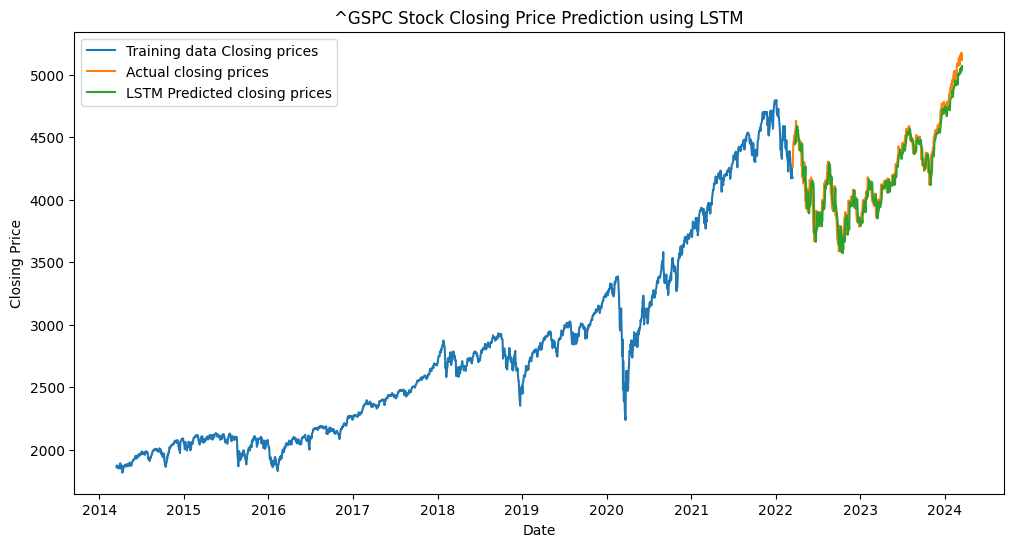

In [25]:
# Display actual vs. predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(closing_prices[:-len(test_data_index)], label="Training data Closing prices")
plt.plot(closing_prices[-len(test_data_index):], label="Actual closing prices")
plt.plot(test_data_index[7:], test_predict[:-1], label="LSTM Predicted closing prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title(f"{symbols} Stock Closing Price Prediction using LSTM")
plt.legend()
plt.show()